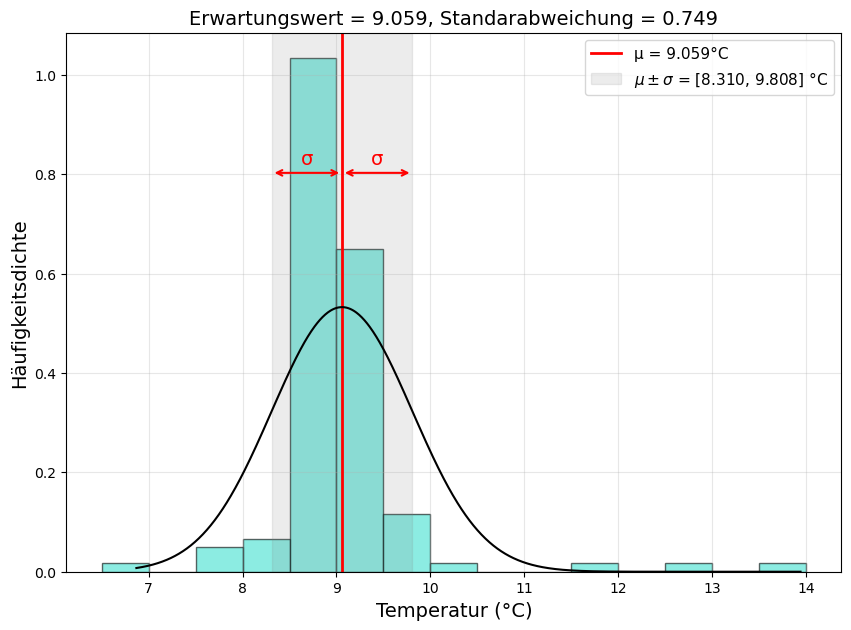

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

#Umbenennen der csv Datei nach aw_daten
#Header muss auf None damit die obere Zeile auch mitgezählt wird
data = pd.read_csv("aw_daten.csv", sep= ";", decimal=",", header=None) 


#relative Häufigkeit

temp = pd.to_numeric(data[0]) #dieser Befehl wandelt erst die Datenzahlen in float Zahlen um

#Äquidistante Klassen festlegen
min_temp = np.floor(temp.min()*2)/2 #für die Optik des Achsenlimits links
max_temp = np.ceil(temp.max()*2)/2 #für die Optik des Achsenlimits rechts

#die Anzahl an Klassen, dafür habe ich verschiedene Werte ausgetestet bis 
#endlich eine Darstellung kam wo die Balken nicht zu eng sowie auch nicht zu weit verbreitet sind,
#weder zu dick noch zu dünn waren

bins = np.linspace(min_temp, max_temp, 16) 

#Histogramm
plt.figure(figsize= (10, 7))
plt.hist(temp, bins=bins, density=True, color = "turquoise", edgecolor = "black", alpha=0.6)
plt.grid(True, alpha= 0.3)

mean = 9.059
std = 0.749

#Beschriftung
plt.title(f"Erwartungswert = {mean:.3f}, Standarabweichung = {std:.3f}" , fontsize =14)
plt.xlabel("Temperatur (°C)", fontsize = 14)
plt.ylabel("Häufigkeitsdichte", fontsize = 14)


#Linie für Erwartungswert und Std.abw. Bereich
plt.axvline(mean, color= "red", linestyle= "-", linewidth=2, label= f"µ = {mean:.3f}°C")
plt.axvspan(mean-std,mean+std, color= "grey", alpha= 0.15, label=rf"$\mu \pm \sigma$ = [{mean - std:.3f}, {mean + std:.3f}] °C")


#Abstand µ - σ
pfeil= plt.ylim()[1] * 0.74
plt.annotate(
    "",
    xy=(mean, pfeil),
    xytext=(mean-std, pfeil),
    arrowprops=dict(
        arrowstyle="<->",
        color="r",
        linewidth=1.5))

plt.text(
    (mean-std + mean) / 2,
    pfeil * 1.02,
    f"σ",
    color="r",
    ha="center",fontsize=14)

#für das Darstellen der Pfeile, Anmerkungen an die Darstellung hinzufügen,
#habe ich dem Anaconda Assistant zu Rate gezogen,
#dabei gab ich ihm bestimmte Proms gegeben zb wie lang die Pfeile sein sollen (1 Stdabstand vom Erwartungswert),
#die Höhe wo die Sigmas stehen sollen , sowie die Höhe wo die Pfeile platziert werden sollen

#Abstand µ + σ
plt.annotate(
    "",
    xy=(mean, pfeil),
    xytext=(mean+std, pfeil),
    arrowprops=dict(
        arrowstyle="<->",
        color="r",
        linewidth=1.5))

plt.text(
    (mean+std + mean) / 2,
    pfeil * 1.02,
    f"σ",
    color="r", 
    ha="center",fontsize=14)

#Normalverteilung
x = np.linspace(min(temp),max(temp),1000)
y = norm.pdf(x, loc=mean, scale=std) #Parameter µ,σ
plt.plot (x, y, color="black", linewidth= 1.5)


plt.legend(fontsize=11, loc= "upper right")
plt.show()